In [1]:
#importa biblioteca
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
#Funções Skearlerning
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector

In [3]:
url='https://raw.githubusercontent.com/Doctor-Math/TP1-Engenharia-de-Software/main/data/bankloans.csv'
bankloans = pd.read_csv(url)

#Tira os valores nulos
df = bankloans.dropna()

In [4]:
#Separa a variavel a ser estimada
X = df.drop('default', axis=1)
y = df['default']

#Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronização
scaler = StandardScaler()

<h2>Identificando variaveis</h2>

Análise das variáveis de maior impacto no histórico de inadimplência, tratamento de outliers nos dados e o estudo da relação entre as características dos clientes.

In [5]:
#Add constante
X_vif = add_constant(df)

#Cria df
vif = pd.DataFrame()
vif["variavel"] = X_vif.columns

#Calcula inflação da variância
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

vif[vif['variavel'] != 'const'].sort_values(by='VIF')

,variavel,VIF
2,ed,1.263713
9,default,1.405265
4,address,1.592315
1,age,2.022854
3,employ,2.401604
7,creddebt,2.615818
6,debtinc,3.370526
8,othdebt,3.861054
5,income,4.215396


A análise do VIF demonstrou valores abaixo de 5, assegurando que não há redundância de informações entre as variáveis selecionadas.

In [6]:
#Correlações
correlacoes = df.dropna().corr()['default'].sort_values(ascending=False)
correlacoes

default     1.000000
debtinc     0.389575
creddebt    0.244740
othdebt     0.145713
ed          0.114676
income     -0.070970
age        -0.137657
address    -0.164451
employ     -0.282978
Name: default, dtype: float64

Considerando que as correlações entre as variáveis e o histórico de inadimplência são baixas, evidencia-se que o modelo não tende seguir uma relação linear. Diante disso, deve se encintrar o  conjunto de variáveis com as maiores ccom maior potencial de avaliar o comportamento multifatorial da inadimplência.

In [7]:
#MODELO COM TODAS AS VARIAVEIS
# Seleciona todas as variáveis
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Treina o modelo
modelo_geral = LogisticRegression(class_weight='balanced')
modelo_geral.fit(X_train_scaled, y_train)

#Previsão
predicoes_g = modelo_geral.predict(X_test_scaled)

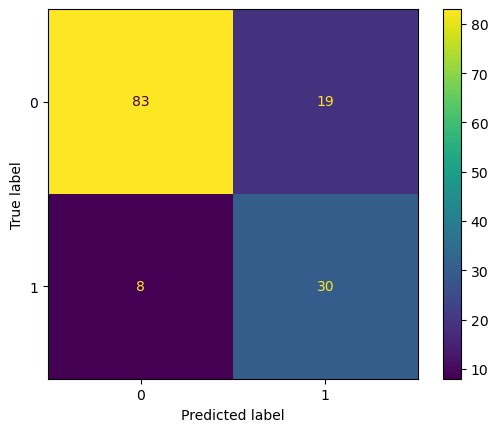

In [8]:
ConfusionMatrixDisplay(confusion_matrix(y_test, predicoes_g)).plot()
plt.show()

Para definir essas variaveis mais relevantes do conjunto, utilizei o método Forward Selection que treina sucessivamente e avalia ,em relação a métrica AUC, como cada variável contribui para a performance do modelo quando combinada com as outras,

In [9]:
resultados = []

for i in range(1, 8):
    #Define SFS para numero de variaveis variando em i, pela métrica auc e com 2 testes por combinação
    sfs = SequentialFeatureSelector(modelo_geral, n_features_to_select=i, direction='forward', scoring='roc_auc', cv=2)

    sfs.fit(X_train_scaled, y_train)
    cols_idx = sfs.get_support()
    
    #Roda modelo 
    modelo_geral.fit(X_train_scaled[:, cols_idx], y_train)
    probs = modelo_geral.predict_proba(X_test_scaled[:, cols_idx])[:, 1]
    preds = modelo_geral.predict(X_test_scaled[:, cols_idx]) 
    
    # Calculo das Métricas
    auc = roc_auc_score(y_test, probs)
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    
    # Organização no df
    resultados.append({
        'n_vars': i,
        'colunas': X.columns[cols_idx].tolist(),
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'taxa_erro': (cm[0, 1] +  cm[1, 0]) / len(y_test)
    })

pd.DataFrame(resultados)

,n_vars,colunas,auc,f1,precision,recall,taxa_erro
0,1,[debtinc],0.807792,0.561798,0.490196,0.657895,0.278571
1,2,"[employ, debtinc]",0.868808,0.689655,0.612245,0.789474,0.192857
2,3,"[employ, debtinc, creddebt]",0.888545,0.666667,0.576923,0.789474,0.214286
3,4,"[employ, address, debtinc, creddebt]",0.906347,0.719101,0.627451,0.842105,0.178571
4,5,"[age, employ, address, debtinc, creddebt]",0.912023,0.688889,0.596154,0.815789,0.200000
5,6,"[age, ed, employ, address, debtinc, creddebt]",0.909443,0.704545,0.620000,0.815789,0.185714
6,7,"[age, ed, employ, address, income, debtinc, cr...",0.910733,0.704545,0.620000,0.815789,0.185714


A análise comparativa demonstra que o modelo composto pelas variáveis [employ, address, debtinc, creddebt] apresenta o desempenho superior entre os cenários testados. Sendo a melhor escolha pelo princípio da parcimônia, pois com um conjunto enxuto de atributos maximiza o AUC, F1-Score e Recall, enquanto minimiza as taxas de erro (falsos positivos e falsos negativos).

In [10]:
#MODELO DA HIPOTESE
# Seleciona apenas as variáveis de melhor desempenho
X_train_scaled = scaler.fit_transform(X_train[['debtinc', 'employ', 'creddebt', 'address']])
X_test_scaled = scaler.transform(X_test[['debtinc', 'employ', 'creddebt', 'address']])

# Treina o modelo
modelo_hipotese = LogisticRegression(class_weight='balanced')
modelo_hipotese.fit(X_train_scaled, y_train)

# Previsão
predicoes_h = modelo_hipotese.predict(X_test_scaled)

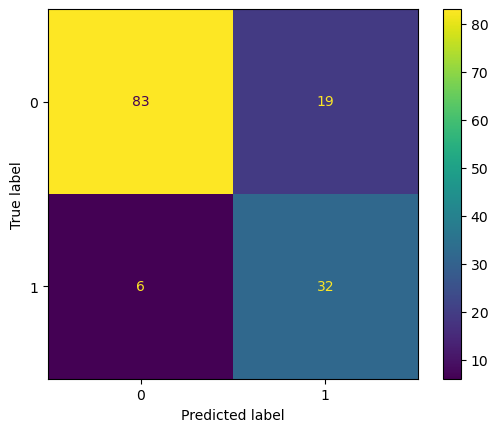

In [11]:
ConfusionMatrixDisplay(confusion_matrix(y_test, predicoes_h)).plot()
plt.show()

In [23]:
# Calcula a predição de probabilidade para todo df
predicoes_prob_h = modelo_hipotese.predict_proba(df[['debtinc', 'employ', 'creddebt', 'address']])[:, 1]
df['prob_inadimplencia'] = predicoes_prob_h.round(5)

df

C:\Users\annyc\OneDrive\Documentos\Coding\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\annyc\AppData\Local\Temp\ipykernel_10608\3493344189.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['prob_inadimplencia'] = predicoes_prob_h.round(5)


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,prob_inadimplencia
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0,0.00000
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0,0.00050
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0,0.00000
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0,0.00000
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0,0.99931
...,...,...,...,...,...,...,...,...,...,...
695,36,2,6,15,27,4.6,0.262062,0.979938,1.0,0.00000
696,29,2,6,4,21,11.5,0.369495,2.045505,0.0,0.00778
697,33,1,15,3,32,7.6,0.491264,1.940736,0.0,0.00000
698,45,1,19,22,77,8.4,2.302608,4.165392,0.0,0.00000
